 Final merged data shape: (211218, 23)

 Correlation Matrix:
                  FearGreed_Value  Closed_PnL  log_Size_USD  Execution Price
FearGreed_Value         1.000000    0.008121     -0.083050        -0.027558
Closed_PnL              0.008121    1.000000      0.081609        -0.006429
log_Size_USD           -0.083050    0.081609      1.000000         0.212564
Execution Price        -0.027558   -0.006429      0.212564         1.000000


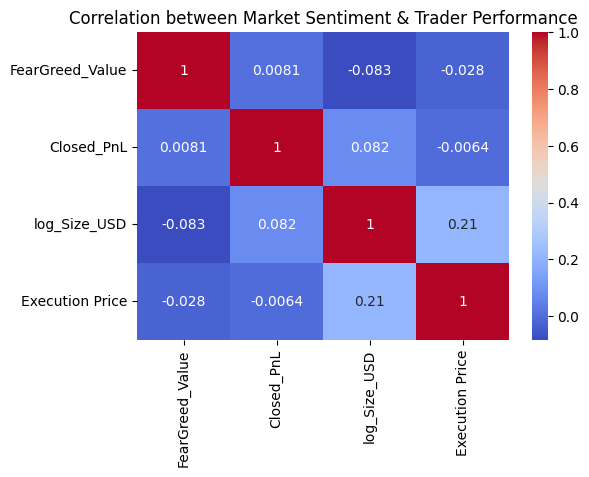


 T-Test between Fear and Greed: T=-0.9875, P=0.3234
 No strong evidence — sentiment may not strongly affect performance.

 Linear Regression Results:
R²: 0.006
MAE: 122.323


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats


fg = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

#merge
fg['date'] = pd.to_datetime(fg['date'])
fg.rename(columns={'value': 'FearGreed_Value', 'classification': 'Sentiment'}, inplace=True)
fg = fg[['date', 'FearGreed_Value', 'Sentiment']]

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce', format='%d-%m-%Y %H:%M')
trades['Date'] = pd.to_datetime(trades['Timestamp IST'].dt.date)

df = pd.merge(trades, fg, left_on='Date', right_on='date', how='inner')

# Feature-eng
df['log_Size_USD'] = np.log1p(df['Size USD'])
df['Closed_PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce')

le = LabelEncoder()
df['Sentiment_Encoded'] = le.fit_transform(df['Sentiment'])

df = df.dropna(subset=['Closed_PnL', 'FearGreed_Value'])

print(" Final merged data shape:", df.shape)


corr = df[['FearGreed_Value', 'Closed_PnL', 'log_Size_USD', 'Execution Price']].corr()
print("\n Correlation Matrix:\n", corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Market Sentiment & Trader Performance")
plt.show()


fear = df[df['Sentiment'].str.contains('Fear', case=False)]['Closed_PnL']
greed = df[df['Sentiment'].str.contains('Greed', case=False)]['Closed_PnL']

t_stat, p_val = stats.ttest_ind(fear.dropna(), greed.dropna(), equal_var=False)
print(f"\n T-Test between Fear and Greed: T={t_stat:.4f}, P={p_val:.4f}")
if p_val < 0.05:
    print(" Significant difference — sentiment influences trader performance.")
else:
    print(" No strong evidence — sentiment may not strongly affect performance.")

#model
features = ['Sentiment_Encoded', 'FearGreed_Value', 'log_Size_USD', 'Execution Price']
X = df[features]
y = df['Closed_PnL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#linear
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lr = linreg.predict(X_test)

print("\n Linear Regression Results:")
print("R²:", round(r2_score(y_test, y_pred_lr), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_lr), 3))

#Random forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n Random Forest Results:")
print("R²:", round(r2_score(y_test, y_pred_rf), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred_rf), 3))

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title("Feature Importance — What Drives Profit Most?")
plt.show()


plt.figure(figsize=(6, 4))
sns.boxplot(x='Sentiment', y='Closed_PnL', data=df, palette='coolwarm')
plt.title("Trader Profit/Loss across Market Sentiments")
plt.show()

